<a href="https://colab.research.google.com/github/adamarsyadfaizin/Pembelajaran-Mesin_2026_3F/blob/main/JS04/JS04_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Regresi — Medical Cost Personal Dataset

Dataset `insurance.csv` berisi 1.338 data dengan target `charges`.

Fitur:
- `age`: usia
- `sex`: jenis kelamin
- `bmi`: body mass index
- `children`: jumlah anak
- `smoker`: status merokok
- `region`: wilayah
- `charges`: biaya medis personal


## Import Library


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


## Load Dataset


In [2]:
data = pd.read_csv('insurance.csv')

print(data.shape)
display(data.head())
data.info()


(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Visualisasi Data


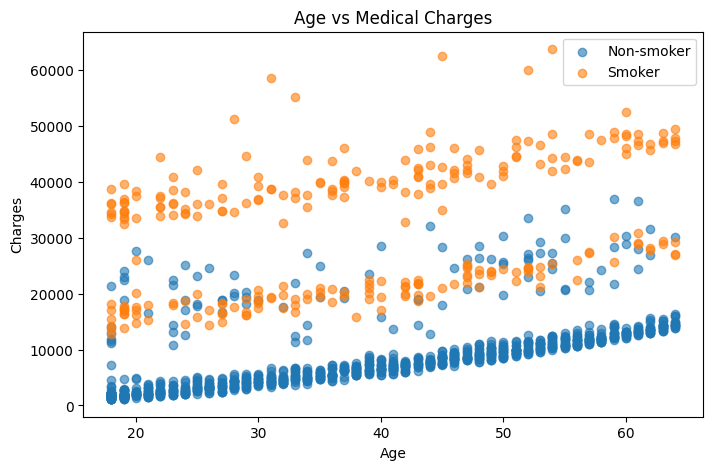

In [3]:
smoker_no = data[data['smoker'] == 'no']
smoker_yes = data[data['smoker'] == 'yes']

plt.figure(figsize=(8, 5))
plt.scatter(smoker_no['age'], smoker_no['charges'], alpha=0.6, label='Non-smoker')
plt.scatter(smoker_yes['age'], smoker_yes['charges'], alpha=0.6, label='Smoker')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Medical Charges')
plt.legend()
plt.show()


## Menentukan Fitur dan Target


In [4]:
X = data.drop(columns='charges')
y = data['charges']

numerical_cols = ['age', 'bmi', 'children']
categorical_cols = ['sex', 'smoker', 'region']


## Membagi Data Train dan Test


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (1070, 6)
Test : (268, 6)


## Multiple Linear Regression


In [6]:
preprocessor_mlr = ColumnTransformer([
    ('num', 'passthrough', numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

mlr = Pipeline([
    ('preprocessor', preprocessor_mlr),
    ('model', LinearRegression())
])

mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)


## Evaluasi Multiple Linear Regression


In [7]:
r2_mlr = r2_score(y_test, y_pred_mlr)
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)

print("R-squared:", r2_mlr)
print("MSE:", mse_mlr)
print("MAE:", mae_mlr)


R-squared: 0.7835929767120724
MSE: 33596915.851361446
MAE: 4181.194473753651


## Support Vector Regression


In [8]:
preprocessor_svr = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

svr_pipeline = Pipeline([
    ('preprocessor', preprocessor_svr),
    ('model', SVR(kernel='rbf'))
])

svr = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)


## Hyperparameter Tuning SVR


In [9]:
param_grid = {
    'regressor__model__C': [1, 10, 100],
    'regressor__model__gamma': ['scale', 0.1, 0.01],
    'regressor__model__epsilon': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    svr,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_svr = grid_search.best_estimator_
y_pred_svr = best_svr.predict(X_test)

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'regressor__model__C': 10, 'regressor__model__epsilon': 0.1, 'regressor__model__gamma': 0.1}


## Evaluasi SVR


In [10]:
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("R-squared:", r2_svr)
print("MSE:", mse_svr)
print("MAE:", mae_svr)


R-squared: 0.8691142393369278
MSE: 20319848.313277826
MAE: 2386.8270838469098


## Perbandingan Model


In [11]:
hasil = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'SVR'],
    'R-squared': [r2_mlr, r2_svr],
    'MSE': [mse_mlr, mse_svr],
    'MAE': [mae_mlr, mae_svr]
})

hasil


,Model,R-squared,MSE,MAE
0,Multiple Linear Regression,0.783593,3.359692e+07,4181.194474
1,SVR,0.869114,2.031985e+07,2386.827084


## Visualisasi Prediksi


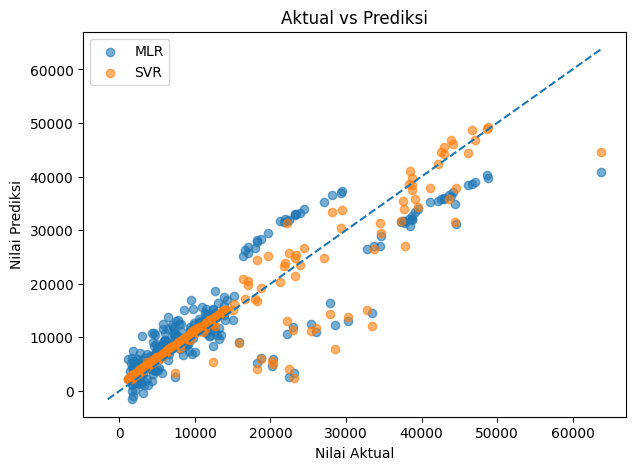

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_mlr, alpha=0.6, label='MLR')
plt.scatter(y_test, y_pred_svr, alpha=0.6, label='SVR')

batas_min = min(y_test.min(), y_pred_mlr.min(), y_pred_svr.min())
batas_max = max(y_test.max(), y_pred_mlr.max(), y_pred_svr.max())

plt.plot([batas_min, batas_max], [batas_min, batas_max], '--')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Aktual vs Prediksi')
plt.legend()
plt.show()


## Analisis Hasil

Dengan pembagian data 80:20 dan `random_state=42`, hasil yang diperoleh:

| Model | R-squared | MSE | MAE |
|---|---:|---:|---:|
| Multiple Linear Regression | 0.7836 | 33,596,915.85 | 4,181.19 |
| SVR | 0.8691 | 20,319,848.31 | 2,386.83 |

Parameter SVR terbaik dari grid yang digunakan adalah `C=10`, `gamma=0.1`, dan `epsilon=0.1`.

Pada pengujian ini, SVR menghasilkan R-squared lebih tinggi serta MSE dan MAE lebih rendah dibandingkan Multiple Linear Regression. Hubungan antara fitur dan biaya medis tidak sepenuhnya linier, sehingga kernel RBF pada SVR dapat menangkap pola yang lebih kompleks.
